IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Libraries loaded successfully
X_test shape  : (384, 21)
y_test (DSR)  : mean=0.3353, std=0.8825
SHAP values shape : (384, 21)
Top 4 features    : ['debt_financial', 'h19_pers_income2', 'housing_debt_balance', 'h19_cin']

=== Part A: Spearman Correlation (Feature Value vs SHAP Value) ===
  sex                      : rho=0.861  p=0.0000  [Monotonic]
  education                : rho=0.767  p=0.0000  [Monotonic]
  marital_status           : rho=0.744  p=0.0000  [Monotonic]
  region                   : rho=0.144  p=0.0047  [Non-monotonic]
  employment_status        : rho=0.702  p=0.0000  [Monotonic]
  employment_type          : rho=0.282  p=0.0000  [Non-monotonic]
  h19_pers_income1         : rho=-0.326  p=0.0000  [Non-monotonic]
  h19_pers_income2         : rho=-0.588  p=0.0000  [Monotonic]
  h19_pers_income4         : rho=0.085  p=0.0979  [Non-monotonic]
  h19_cin                  : rho=0.527  p=0.0000  [Monotonic]
  h19_din                  : rho=-0.451  p=0.0000  [Non-monotonic]
  debt_

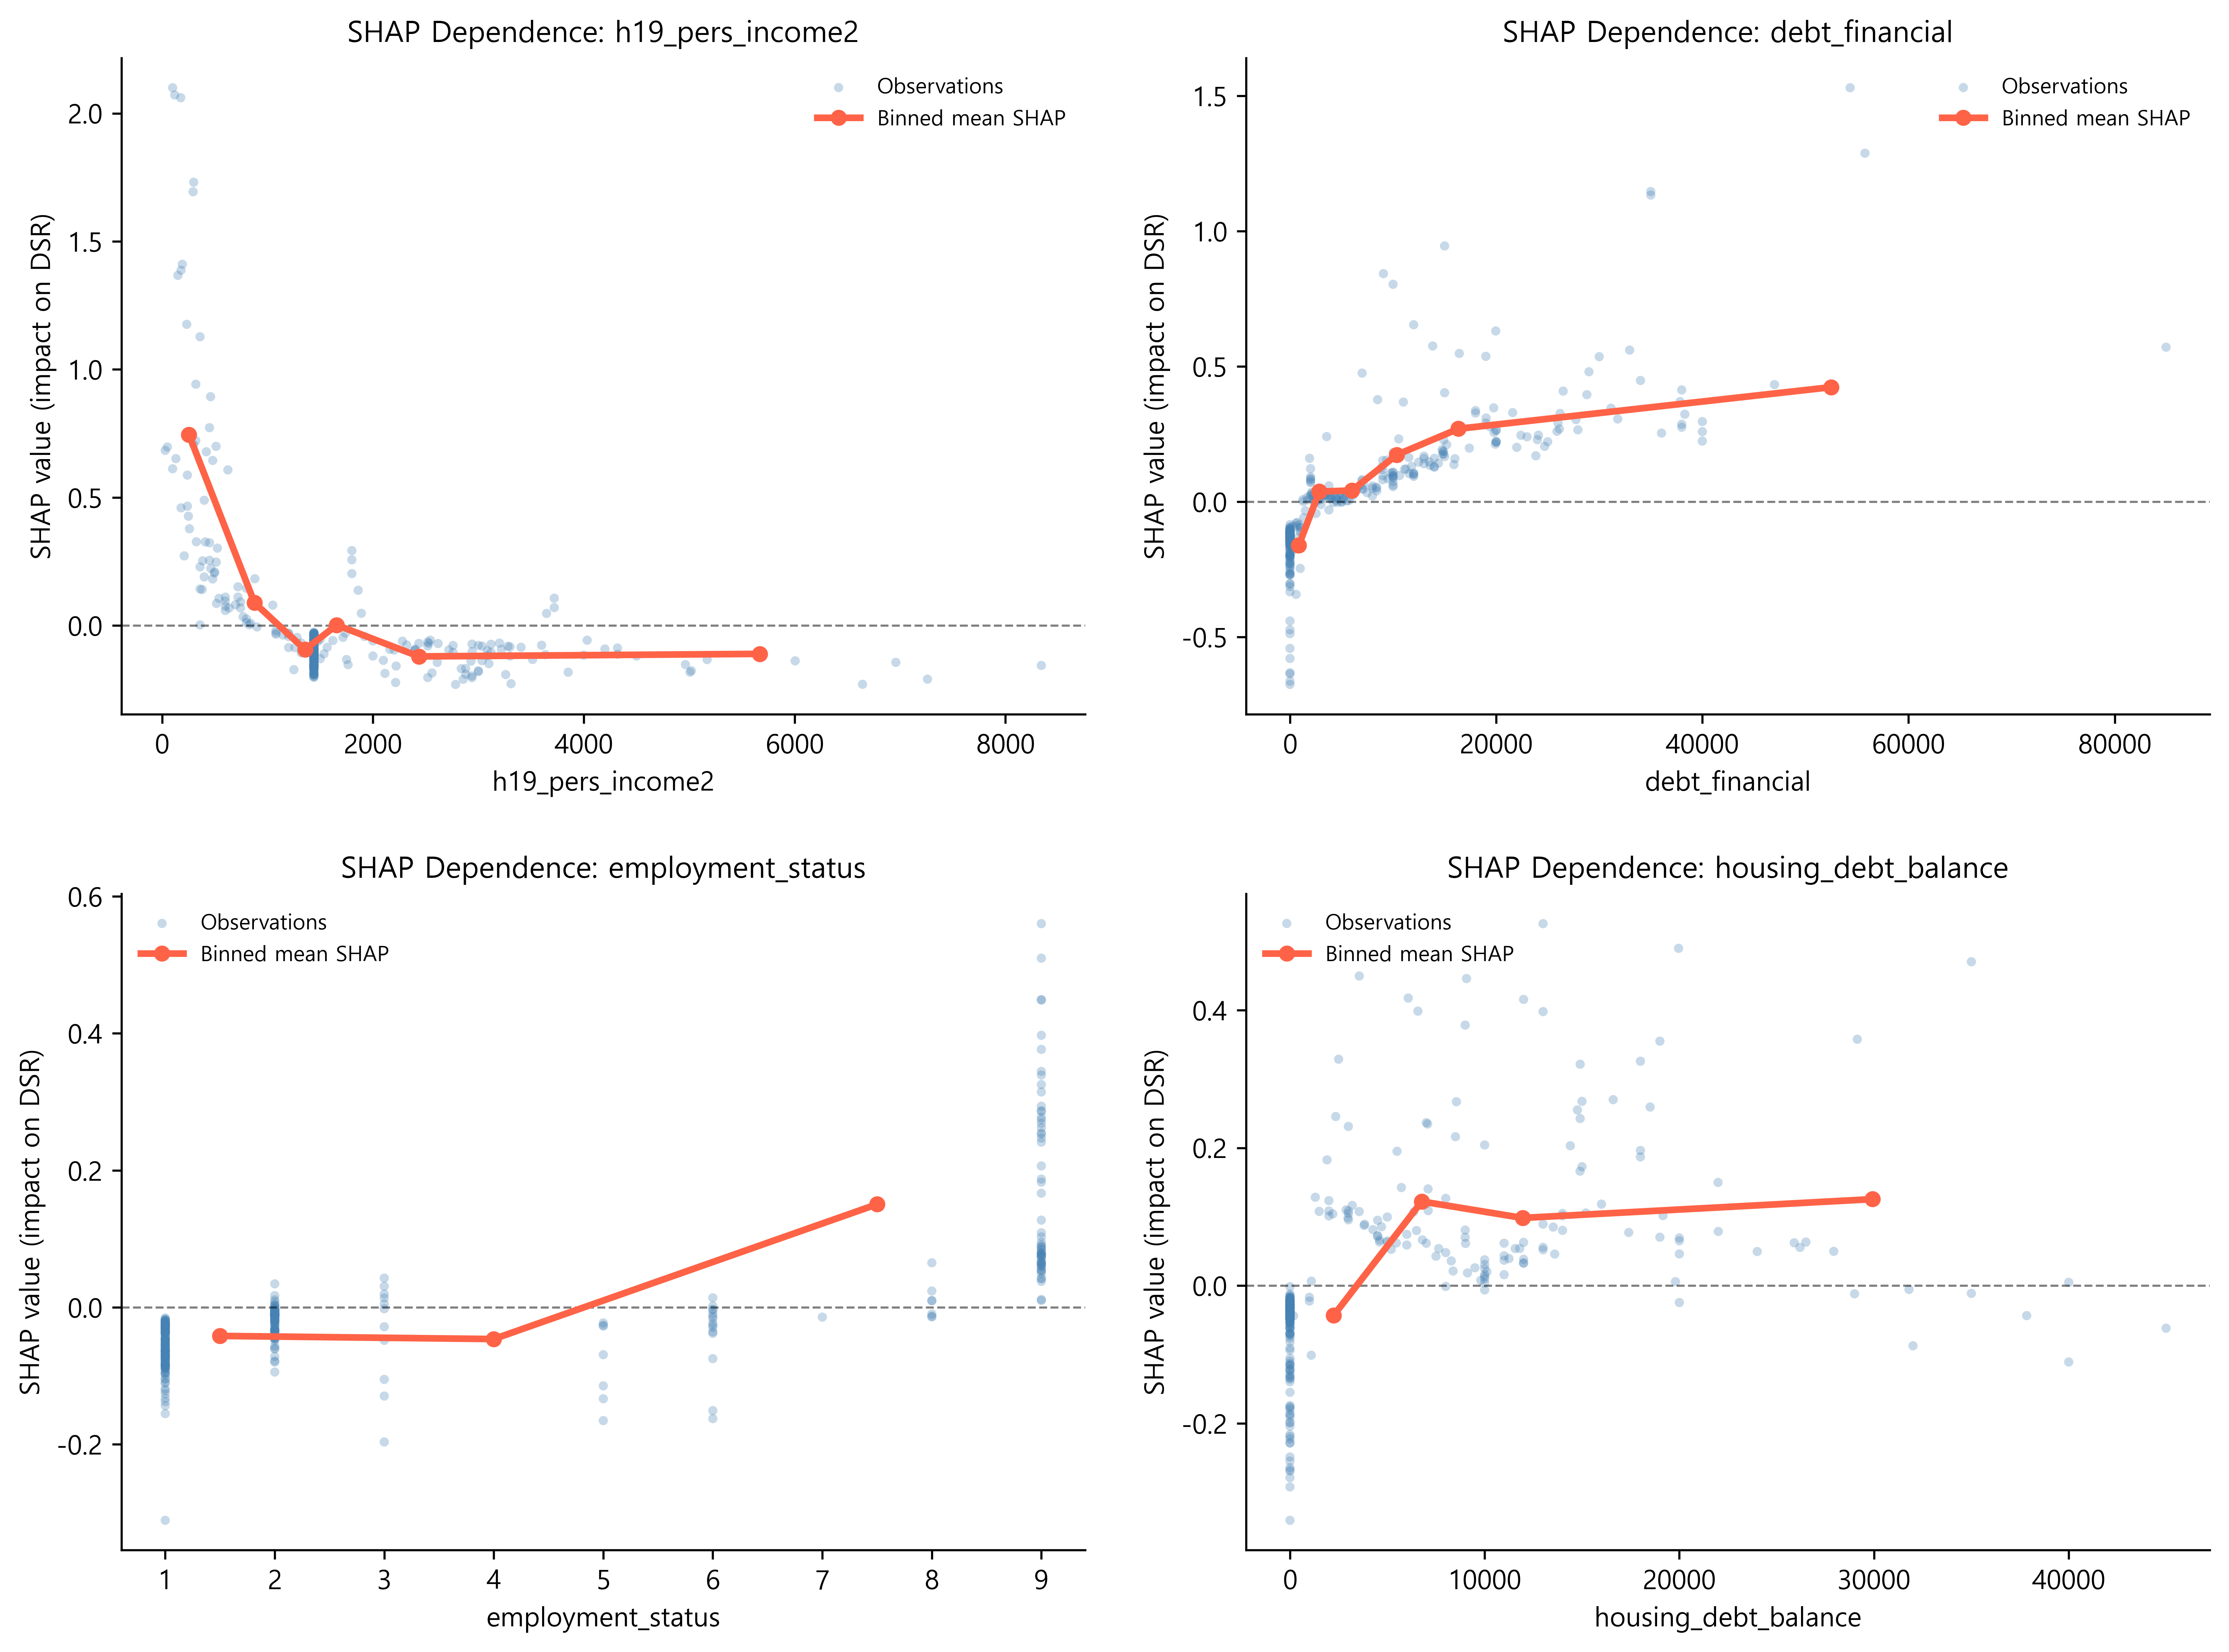

Saved -> outputs/35_shap_nonlinear_dependence_reg.png

=== Part A: h19_pers_income2 Inflection Analysis ===
  Median (positive values) : 1440.0
  Low group  (n=293): mean SHAP = 0.0437
  High group (n= 91): mean SHAP = -0.0975
  Direction reversal: YES — non-monotonic


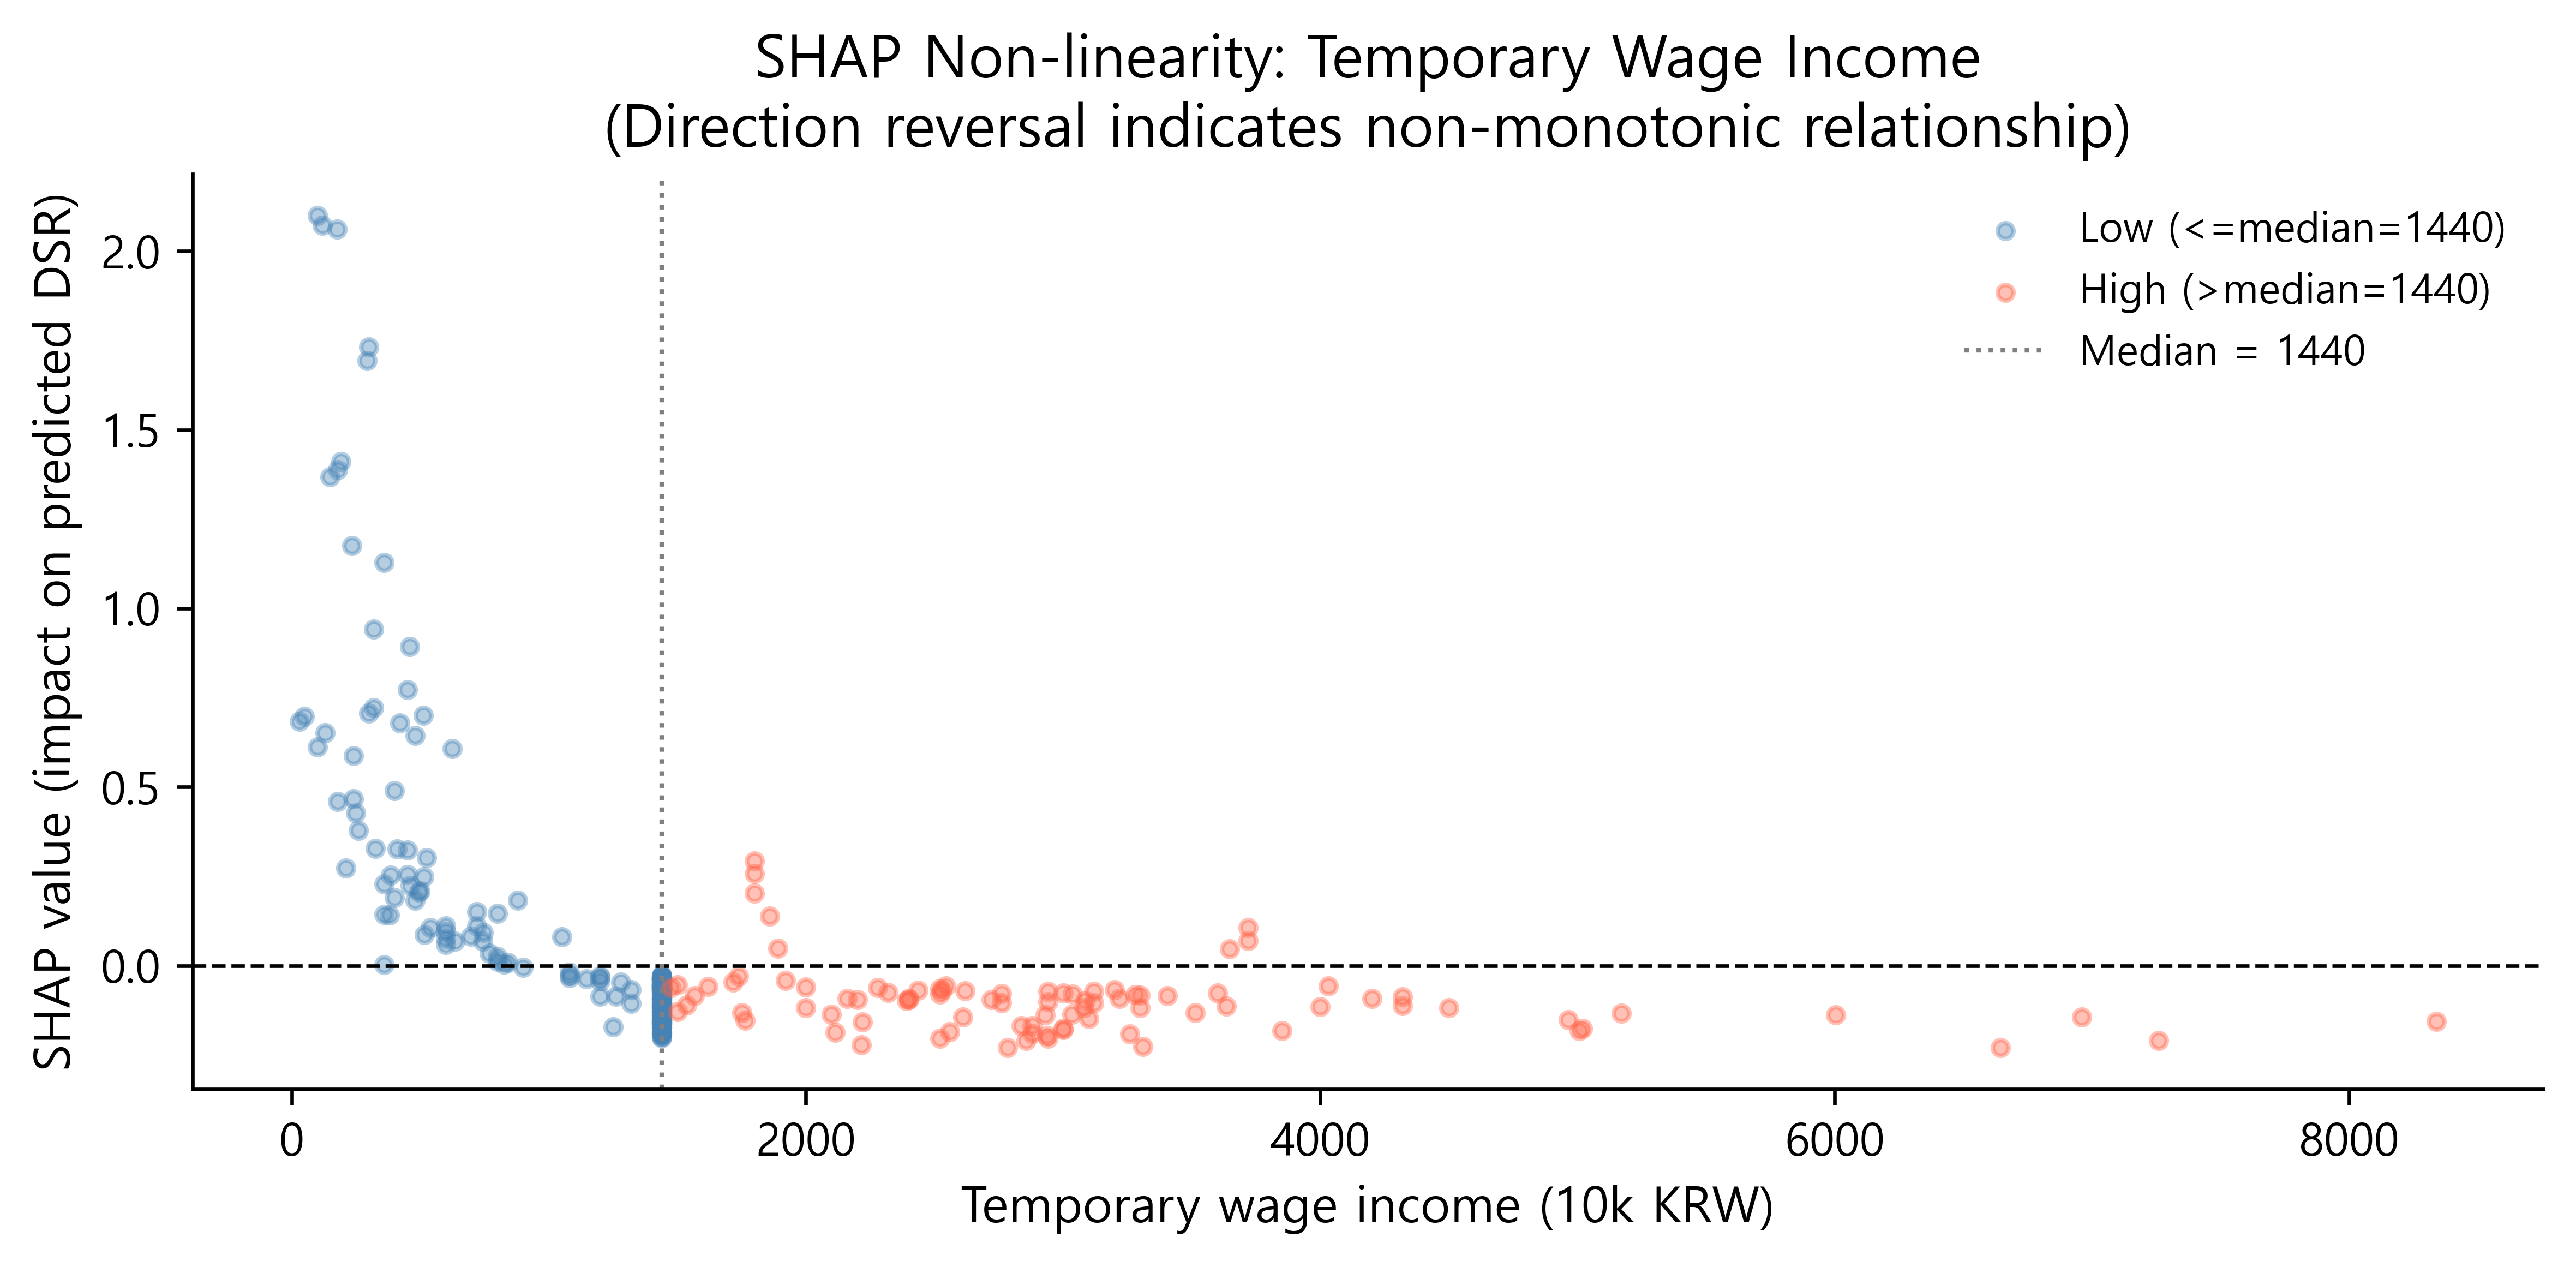

Saved -> outputs/36_shap_income2_inflection_reg.png

=== Part B: CF Actionability Filtering ===
Non-actionable features: ['age', 'sex', 'marital_status', 'region', 'education']
Rationale:
  age            : cannot be changed through policy
  sex            : immutable demographic
  marital_status : not a direct policy target
  region         : residential relocation not a short-term lever
  education      : long-term; not an immediate intervention

  Total CF cases           : 10
  Contaminated (NA feats)  : 5
  Clean (actionable only)  : 5

  Non-actionable feature frequency:
    age: 3x
    education: 1x
    sex: 1x

  Contaminated cases:
 case_id  n_changes_total non_actionable_feats                                                                        actionable_feats  n_non_actionable  n_actionable
      24                3                  age                                                     employment_status, h19_pers_income2                 1             2
      28         

100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


  idx=1: pred 0.549 -> 0.174 | changes=2 ['h19_pers_income4', 'debt_card']


100%|██████████| 1/1 [00:00<00:00,  3.13it/s]


  idx=3: pred 1.519 -> 0.183 | changes=1 ['h19_pers_income2']


...

  idx=35: pred 2.101 -> 0.187 | changes=4 ['employment_status', 'h19_pers_income2', 'debt_lease', 'total_debt']


100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


  idx=42: pred 2.264 -> 0.099 | changes=7 ['employment_status', 'h19_pers_income2', 'debt_financial', 'debt_card', 'debt_lease', 'debt_other', 'housing_debt_balance']


100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


  idx=45: pred 2.369 -> 0.122 | changes=4 ['employment_status', 'h19_pers_income2', 'debt_card', 'housing_debt_balance']

Actionable CF success: 10 / 10

=== Actionability Constraint Impact ===

  [Unconstrained CF1]
  Achievement rate  : 100%
  Mean n_changes    : 3.20
  Non-actionable contamination: 5/10 cases

  [Actionable-only CF]
  Achievement rate  : 100%
  Mean n_changes    : 3.40
  Non-actionable contamination: 0/10 cases (by design)

  Feature frequency comparison:
             Feature  Unconstrained  Actionable-only
   employment_status              5                6
    h19_pers_income2              6                5
          debt_lease              2                4
           debt_card              1                4
      housing_tenure              1                2
      debt_financial              1                2
housing_debt_balance              2                2
    h19_pers_income4              1                2
             h19_cin              1        

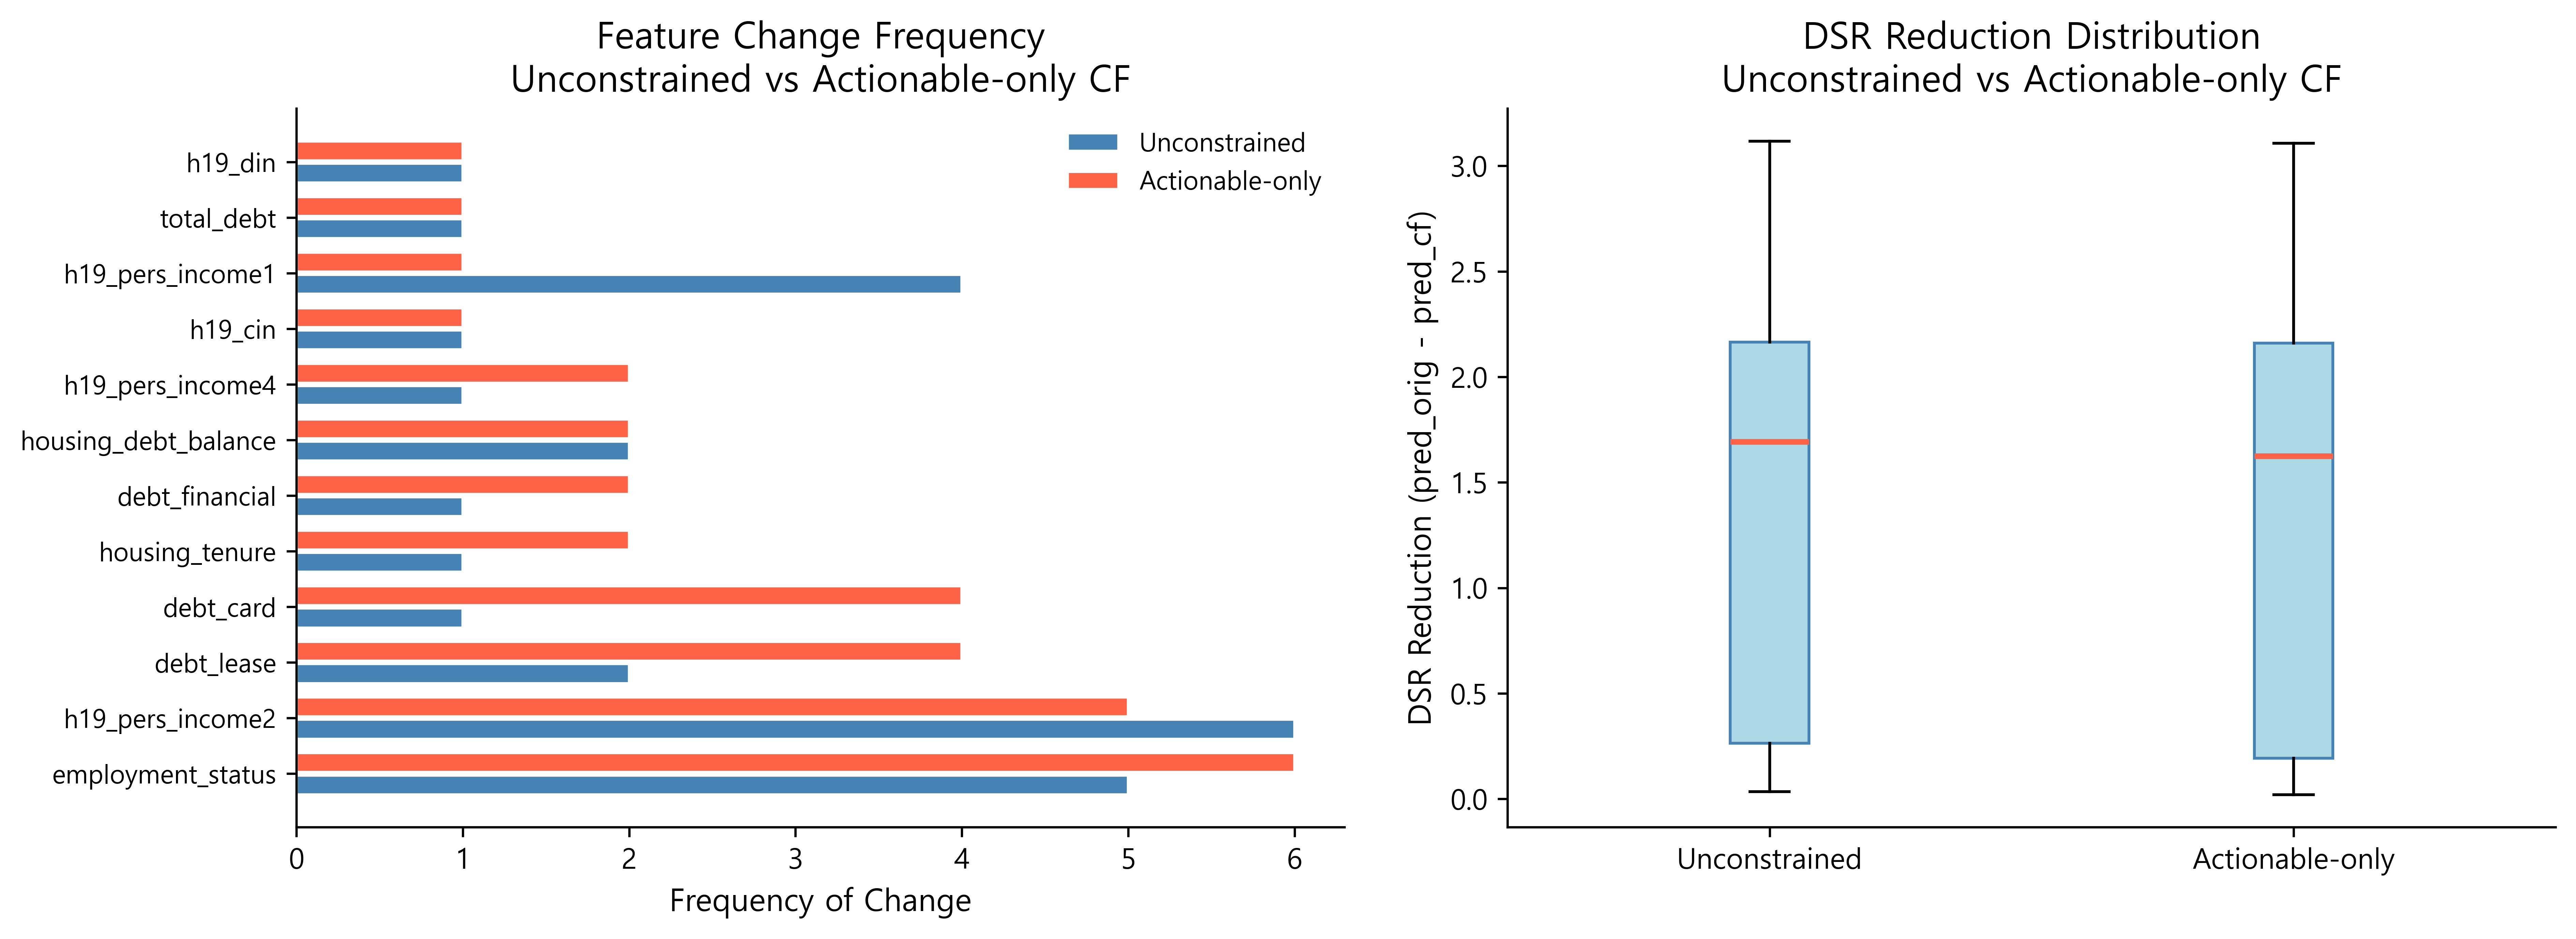

Saved -> outputs/37_actionability_comparison_reg.png


In [1]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 10_shap_nonlinear_cf_actionability_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Part A — SHAP non-linear dependence analysis
#                       Quantify non-monotonic relationships between
#                       key features and predicted DSR
#             Part B — CF actionability filtering
#                       Exclude non-actionable features (age, sex) from
#                       DiCE CFs and measure impact on achievement rate
# Data      : X_test_reg.csv, y_test_reg.csv, model_lgbm_reg.pkl,
#             dice_cf_summary_reg.csv, dice_cf_full_reg.csv
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import shap
import warnings
import joblib
import dice_ml
from dice_ml import Dice
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW  = dict(dpi=600, bbox_inches='tight', format='png')
DSR_THR  = 0.4

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test  = pd.read_csv('../data/X_test_reg.csv')
y_test  = pd.read_csv('../data/y_test_reg.csv').squeeze()
X_train = pd.read_csv('../data/X_train_reg.csv')
y_train = pd.read_csv('../data/y_train_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

feature_names = X_train.columns.tolist()

print(f"X_test shape  : {X_test_r.shape}")
print(f"y_test (DSR)  : mean={y_test_r.mean():.4f}, std={y_test_r.std():.4f}")


# ═══════════════════════════════════════════════════════════════
# PART A | SHAP Non-linear Dependence Analysis
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 3 | Compute SHAP values
# ─────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_r)
sv          = shap_values
exp_val     = float(explainer.expected_value)

mean_shap = pd.Series(np.abs(sv).mean(axis=0),
                       index=feature_names).sort_values(ascending=False)
top4 = mean_shap.index[:4].tolist()

print(f"SHAP values shape : {sv.shape}")
print(f"Top 4 features    : {top4}")


# ─────────────────────────────────────────────
# Cell 4 | Non-monotonicity test
# Spearman correlation between feature value and SHAP value
# |rho| < 0.7 with visible inflection -> non-monotonic flag
# ─────────────────────────────────────────────
from scipy.stats import spearmanr

print("\n=== Part A: Spearman Correlation (Feature Value vs SHAP Value) ===")
mono_rows = []

for feat in feature_names:
    feat_vals  = X_test_r[feat].values
    shap_vals  = sv[:, feature_names.index(feat)]
    rho, pval  = spearmanr(feat_vals, shap_vals)

    # Non-monotonic flag: low |rho| suggests non-monotonic relationship
    flag = 'Non-monotonic' if abs(rho) < 0.5 else 'Monotonic'

    mono_rows.append({
        'Feature'  : feat,
        'Spearman rho': round(rho, 3),
        'p-value'  : round(pval, 4),
        'Pattern'  : flag,
    })
    print(f"  {feat:<25}: rho={rho:.3f}  p={pval:.4f}  [{flag}]")

mono_df = pd.DataFrame(mono_rows).sort_values('Spearman rho')
mono_df.to_csv('../outputs/shap_monotonicity_reg.csv',
               index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/shap_monotonicity_reg.csv")


# ─────────────────────────────────────────────
# Cell 5 | Partial dependence: binned mean SHAP by feature decile
# Reveals inflection points in the SHAP-feature relationship
# ─────────────────────────────────────────────
focus_feats = ['h19_pers_income2', 'debt_financial',
               'employment_status', 'housing_debt_balance']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, feat in zip(axes, focus_feats):
    feat_vals = X_test_r[feat].values
    shap_vals = sv[:, feature_names.index(feat)]

    # Scatter
    ax.scatter(feat_vals, shap_vals,
               alpha=0.3, s=12, color='steelblue', edgecolor='none',
               zorder=2, label='Observations')

    # Binned mean SHAP (10 bins)
    try:
        bins     = pd.qcut(feat_vals, q=10, duplicates='drop')
        bin_mid  = feat_vals.copy()
        bin_mean = pd.Series(shap_vals).groupby(bins).mean()
        bin_centers = [interval.mid for interval in bin_mean.index]
        ax.plot(bin_centers, bin_mean.values,
                color='tomato', lw=2.5, marker='o', markersize=5,
                zorder=3, label='Binned mean SHAP')
    except Exception:
        pass

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP value (impact on DSR)', fontsize=10)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/35_shap_nonlinear_dependence_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/35_shap_nonlinear_dependence_reg.png")


# ─────────────────────────────────────────────
# Cell 6 | h19_pers_income2 inflection quantification
# Split at median: low vs high temporary income
# Compare mean SHAP direction in each half
# ─────────────────────────────────────────────
feat      = 'h19_pers_income2'
feat_idx  = feature_names.index(feat)
feat_vals = X_test_r[feat].values
shap_vals = sv[:, feat_idx]

median_val = np.median(feat_vals[feat_vals > 0]) if (feat_vals > 0).any() else np.median(feat_vals)
low_mask   = feat_vals <= median_val
high_mask  = feat_vals > median_val

print(f"\n=== Part A: {feat} Inflection Analysis ===")
print(f"  Median (positive values) : {median_val:.1f}")
print(f"  Low group  (n={low_mask.sum():>3}): mean SHAP = {shap_vals[low_mask].mean():.4f}")
print(f"  High group (n={high_mask.sum():>3}): mean SHAP = {shap_vals[high_mask].mean():.4f}")
print(f"  Direction reversal: "
      f"{'YES — non-monotonic' if (shap_vals[low_mask].mean() * shap_vals[high_mask].mean() < 0) else 'NO — monotonic'}")

# Visualize split
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(feat_vals[low_mask], shap_vals[low_mask],
           alpha=0.4, s=12, color='steelblue', label=f'Low (<=median={median_val:.0f})')
ax.scatter(feat_vals[high_mask], shap_vals[high_mask],
           alpha=0.4, s=12, color='tomato', label=f'High (>median={median_val:.0f})')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axvline(median_val, color='gray', lw=1.0, linestyle=':',
           label=f'Median = {median_val:.0f}')
ax.set_xlabel('Temporary wage income (10k KRW)', fontsize=11)
ax.set_ylabel('SHAP value (impact on predicted DSR)', fontsize=11)
ax.set_title('SHAP Non-linearity: Temporary Wage Income\n'
             '(Direction reversal indicates non-monotonic relationship)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/36_shap_income2_inflection_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/36_shap_income2_inflection_reg.png")


# ═══════════════════════════════════════════════════════════════
# PART B | CF Actionability Filtering
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 7 | Define non-actionable features
# Features that cannot be changed through policy intervention
# ─────────────────────────────────────────────
NON_ACTIONABLE = ['age', 'sex', 'marital_status', 'region', 'education']

print("\n=== Part B: CF Actionability Filtering ===")
print(f"Non-actionable features: {NON_ACTIONABLE}")
print("Rationale:")
print("  age            : cannot be changed through policy")
print("  sex            : immutable demographic")
print("  marital_status : not a direct policy target")
print("  region         : residential relocation not a short-term lever")
print("  education      : long-term; not an immediate intervention")


# ─────────────────────────────────────────────
# Cell 8 | Analyse existing CFs for non-actionable contamination
# Load CF results and flag cases with non-actionable changes
# ─────────────────────────────────────────────
cf_summary = pd.read_csv('../outputs/dice_cf_summary_reg.csv')
cf_full    = pd.read_csv('../outputs/dice_cf_full_reg.csv')

contaminated   = []
clean          = []
na_feat_counts = Counter()

for _, row in cf_summary.iterrows():
    changed = [f.strip() for f in str(row['changed_features']).split(',')]
    na_feats = [f for f in changed if f in NON_ACTIONABLE]
    ac_feats = [f for f in changed if f not in NON_ACTIONABLE]

    if na_feats:
        contaminated.append({
            'case_id'              : row['case_id'],
            'n_changes_total'      : row['n_changes_cf1'],
            'non_actionable_feats' : ', '.join(na_feats),
            'actionable_feats'     : ', '.join(ac_feats),
            'n_non_actionable'     : len(na_feats),
            'n_actionable'         : len(ac_feats),
        })
        na_feat_counts.update(na_feats)
    else:
        clean.append(row['case_id'])

print(f"\n  Total CF cases           : {len(cf_summary)}")
print(f"  Contaminated (NA feats)  : {len(contaminated)}")
print(f"  Clean (actionable only)  : {len(clean)}")
print(f"\n  Non-actionable feature frequency:")
for feat, cnt in na_feat_counts.most_common():
    print(f"    {feat}: {cnt}x")

cont_df = pd.DataFrame(contaminated) if contaminated else pd.DataFrame()
if len(cont_df) > 0:
    print("\n  Contaminated cases:")
    print(cont_df.to_string(index=False))


# ─────────────────────────────────────────────
# Cell 9 | Re-generate CFs with actionability constraints
# Exclude non-actionable features from DiCE feature space
# ─────────────────────────────────────────────
ACTIONABLE_FEATS = [f for f in feature_names if f not in NON_ACTIONABLE]

print(f"\n  Actionable features ({len(ACTIONABLE_FEATS)}): {ACTIONABLE_FEATS}")

# Build DiCE with actionable features only
X_train_act = X_train[ACTIONABLE_FEATS].copy().astype(float)
y_train_act = y_train.copy().astype(float)

df_train_act        = X_train_act.copy()
df_train_act['dsr'] = y_train_act.values

# Wrapper: predict using full feature set (pad non-actionable with original values)
X_test_full = X_test_r.copy().astype(float)

# We pass only actionable features to DiCE data interface
# but predict using full model by padding non-actionable features
# with the original instance values
class ActionableWrapper:
    """Predict DSR using full model, padding non-actionable features
    with a fixed reference row."""
    def __init__(self, model, full_feat_names, act_feat_names,
                 na_feats, reference_row):
        self.model         = model
        self.full_feats    = full_feat_names
        self.act_feats     = act_feat_names
        self.na_feats      = na_feats
        self.ref           = reference_row  # dict of non-actionable values

    def predict(self, X_act):
        """X_act: array/df with actionable features only."""
        if hasattr(X_act, 'values'):
            X_act = X_act.values
        n = X_act.shape[0]
        X_full = np.zeros((n, len(self.full_feats)))
        for j, feat in enumerate(self.full_feats):
            if feat in self.act_feats:
                idx = self.act_feats.index(feat)
                X_full[:, j] = X_act[:, idx]
            else:
                X_full[:, j] = self.ref.get(feat, 0)
        return self.model.predict(X_full)


# ─────────────────────────────────────────────
# Cell 10 | Run actionable CF generation
# Compare achievement rate and sparsity with/without constraints
# ─────────────────────────────────────────────
high_dsr_idx = y_test_r[y_test_r >= DSR_THR].index.tolist()[:10]

results_act = []
N_BOOT_CF   = 1000

for idx in high_dsr_idx:
    instance_full = X_test_full.iloc[[idx]].copy()
    dsr_orig      = float(y_test_r.iloc[idx])
    pred_orig     = float(lgbm.predict(instance_full.values)[0])

    # Reference: non-actionable feature values from this instance
    ref_vals = {f: float(instance_full[f].iloc[0]) for f in NON_ACTIONABLE
                if f in instance_full.columns}

    wrapper = ActionableWrapper(
        lgbm, feature_names, ACTIONABLE_FEATS, NON_ACTIONABLE, ref_vals)

    instance_act = instance_full[ACTIONABLE_FEATS].copy()

    # Build per-instance DiCE
    df_ref          = df_train_act.copy()
    data_iface      = dice_ml.Data(
        dataframe           = df_ref,
        continuous_features = ACTIONABLE_FEATS,
        outcome_name        = 'dsr'
    )
    model_iface = dice_ml.Model(
        model      = wrapper,
        backend    = 'sklearn',
        model_type = 'regressor'
    )
    dice_exp = Dice(data_iface, model_iface, method='random')

    try:
        cf_obj   = dice_exp.generate_counterfactuals(
            instance_act,
            total_CFs     = 1,
            desired_range = [0.0, 0.2],
        )
        cf_feats = cf_obj.cf_examples_list[0].final_cfs_df
        if cf_feats is None or len(cf_feats) == 0:
            print(f"  idx={idx}: No CF found")
            continue

        cf_feats  = cf_feats.drop(columns=['dsr'], errors='ignore')
        pred_cf   = float(wrapper.predict(cf_feats.iloc[[0]].values)[0])
        diff_mask = (instance_act.iloc[0].values != cf_feats.iloc[0].values)
        changed   = [ACTIONABLE_FEATS[k] for k in range(len(ACTIONABLE_FEATS))
                     if k < len(diff_mask) and diff_mask[k]]

        results_act.append({
            'case_id'         : idx,
            'dsr_actual'      : round(dsr_orig, 4),
            'pred_orig'       : round(pred_orig, 4),
            'pred_cf'         : round(pred_cf, 4),
            'dsr_reduction'   : round(pred_orig - pred_cf, 4),
            'n_changes'       : int(diff_mask.sum()),
            'changed_features': ', '.join(changed),
            'achieved'        : int(0.0 <= pred_cf <= 0.2),
        })
        print(f"  idx={idx}: pred {pred_orig:.3f} -> {pred_cf:.3f} "
              f"| changes={int(diff_mask.sum())} {changed}")

    except Exception as e:
        print(f"  idx={idx}: Failed — {e}")

print(f"\nActionable CF success: {len(results_act)} / {len(high_dsr_idx)}")


# ─────────────────────────────────────────────
# Cell 11 | Compare unconstrained vs actionable CFs
# ─────────────────────────────────────────────
act_df = pd.DataFrame(results_act) if results_act else pd.DataFrame()

# Unconstrained CF1 results (from 05_dice)
unc_df = cf_summary.copy()

print("\n=== Actionability Constraint Impact ===")
if len(act_df) > 0:
    print(f"\n  [Unconstrained CF1]")
    print(f"  Achievement rate  : "
          f"{(unc_df['dsr_pred_cf1'] <= 0.2).mean():.0%}")
    print(f"  Mean n_changes    : {unc_df['n_changes_cf1'].mean():.2f}")
    print(f"  Non-actionable contamination: "
          f"{len(contaminated)}/{len(unc_df)} cases")

    print(f"\n  [Actionable-only CF]")
    print(f"  Achievement rate  : {act_df['achieved'].mean():.0%}")
    print(f"  Mean n_changes    : {act_df['n_changes'].mean():.2f}")
    print(f"  Non-actionable contamination: 0/{len(act_df)} cases (by design)")

    # Feature frequency comparison
    act_changed = []
    for _, row in act_df.iterrows():
        act_changed.extend([f.strip() for f in
                            str(row['changed_features']).split(',')])
    act_freq = Counter(act_changed)

    unc_changed = []
    for _, row in unc_df.iterrows():
        unc_changed.extend([f.strip() for f in
                            str(row['changed_features']).split(',')])
    unc_freq = Counter(unc_changed)

    all_feats  = sorted(set(list(act_freq.keys()) + list(unc_freq.keys())))
    compare_df = pd.DataFrame({
        'Feature'        : all_feats,
        'Unconstrained'  : [unc_freq.get(f, 0) for f in all_feats],
        'Actionable-only': [act_freq.get(f, 0) for f in all_feats],
    }).sort_values('Actionable-only', ascending=False)

    print("\n  Feature frequency comparison:")
    print(compare_df.to_string(index=False))

    # Save
    act_df.to_csv('../outputs/cf_actionable_reg.csv',
                  index=False, encoding='utf-8-sig')
    compare_df.to_csv('../outputs/cf_actionability_comparison_reg.csv',
                      index=False, encoding='utf-8-sig')
    print("\nSaved -> outputs/cf_actionable_reg.csv")
    print("Saved -> outputs/cf_actionability_comparison_reg.csv")


# ─────────────────────────────────────────────
# Cell 12 | Visualize: unconstrained vs actionable CF comparison
# ─────────────────────────────────────────────
if len(act_df) > 0 and len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # (1) Feature frequency comparison bar chart
    top_feats = compare_df.head(12)
    y_pos     = np.arange(len(top_feats))

    axes[0].barh(y_pos - 0.2, top_feats['Unconstrained'], height=0.35,
                 color='steelblue', label='Unconstrained', edgecolor='white')
    axes[0].barh(y_pos + 0.2, top_feats['Actionable-only'], height=0.35,
                 color='tomato', label='Actionable-only', edgecolor='white')
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(top_feats['Feature'], fontsize=9)
    axes[0].set_xlabel('Frequency of Change')
    axes[0].set_title('Feature Change Frequency\nUnconstrained vs Actionable-only CF')
    axes[0].legend(frameon=False, fontsize=9)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # (2) DSR reduction comparison
    unc_red  = (unc_df['dsr_pred_original'] - unc_df['dsr_pred_cf1']).values
    act_red  = act_df['dsr_reduction'].values

    axes[1].boxplot([unc_red, act_red],
                    labels=['Unconstrained', 'Actionable-only'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
    axes[1].set_ylabel('DSR Reduction (pred_orig - pred_cf)')
    axes[1].set_title('DSR Reduction Distribution\nUnconstrained vs Actionable-only CF')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout(pad=2.0)
    plt.savefig('../outputs/37_actionability_comparison_reg.png', **SAVE_KW)
    plt.show()
    print("Saved -> outputs/37_actionability_comparison_reg.png")